In [9]:
%pip install networkx pandas matplotlib folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Graph Setup

Goal: represent road network as Python object.
Representation:
- Nodes: Locations that we want to visit or pass through.
- Edges: roads connecting these location, each with a travel time in minutes.


In [10]:
WAYPOINTS = [
    "Karatu",
    "Lodoare Gate",
    "Olduvai Gorge",
    "Naabi Hill",
    "Simba Kopjes",
    "Ndutu",
    "Moru Kopjes",
    "Seronera",
    "Retima",
    "Lobo",
    "Klein's Gate"
]

Each edge is a tuple of (origin, destination, travel_time_minutes).
- travel_time_minutes is a estimation - can be obtained via Google Maps API.

In [11]:
EDGES = [
    ("Karatu",        "Lodoare Gate",  60,  "main_road",    "low"),
    ("Lodoare Gate",  "Olduvai Gorge", 45,  "main_road",    "low"),
    ("Olduvai Gorge", "Naabi Hill",    60,  "main_road",    "low"),
    ("Naabi Hill",    "Simba Kopjes",  30,  "direct_track", "high"),
    ("Naabi Hill",    "Simba Kopjes",  55,  "main_road",    "low"),
    ("Naabi Hill",    "Ndutu",         75,  "direct_track", "high"),
    ("Naabi Hill",    "Ndutu",         100, "main_road",    "low"),
    ("Simba Kopjes",  "Seronera",      45,  "main_road",    "low"),
    ("Ndutu",         "Seronera",      90,  "main_road",    "low"),
    ("Seronera",      "Moru Kopjes",   45,  "black_cotton", "high"),
    ("Seronera",      "Moru Kopjes",   75,  "alternate",    "low"),
    ("Seronera",      "Retima",        60,  "main_road",    "low"),
    ("Retima",        "Lobo",          90,  "black_cotton", "high"),
    ("Retima",        "Lobo",          130, "main_road",    "low"),
    ("Lobo",          "Klein's Gate",  60,  "main_road",    "low"),
    ("Moru Kopjes",   "Karatu",        120, "main_road",    "low"),
    ("Klein's Gate",  "Karatu",        180, "main_road",    "low"),
]

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(WAYPOINTS)

for origin, destination, time, type_road, risk in EDGES:
    G.add_edge(origin, destination, travel_time=time, type_road=type_road, risk=risk)


print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 11, Edges: 13


In [13]:
for u, v, data in G.edges(data=True):
    print(f"  {u} -> {v}: {data['travel_time']} min")

  Karatu -> Lodoare Gate: 60 min
  Karatu -> Moru Kopjes: 120 min
  Karatu -> Klein's Gate: 180 min
  Lodoare Gate -> Olduvai Gorge: 45 min
  Olduvai Gorge -> Naabi Hill: 60 min
  Naabi Hill -> Simba Kopjes: 55 min
  Naabi Hill -> Ndutu: 100 min
  Simba Kopjes -> Seronera: 45 min
  Ndutu -> Seronera: 90 min
  Moru Kopjes -> Seronera: 75 min
  Seronera -> Retima: 60 min
  Retima -> Lobo: 130 min
  Lobo -> Klein's Gate: 60 min


In [14]:
pos = nx.spring_layout(G, seed=42)
pos

{'Karatu': array([ 0.54017313, -0.27569785]),
 'Lodoare Gate': array([-0.24627085, -0.34831769]),
 'Olduvai Gorge': array([-0.85470755, -0.06745204]),
 'Naabi Hill': array([-0.91464361,  0.5293664 ]),
 'Simba Kopjes': array([-0.45711672,  0.86902705]),
 'Ndutu': array([-0.51805081,  0.56043362]),
 'Moru Kopjes': array([0.56153124, 0.28359994]),
 'Seronera': array([0.0014771 , 0.37677724]),
 'Retima': array([ 0.25104348, -0.35709837]),
 'Lobo': array([ 0.6365646 , -0.88682975]),
 "Klein's Gate": array([ 1.        , -0.68380855])}

In [15]:
edge_labels = nx.get_edge_attributes(G, 'travel_time')

C:\Users\Juan\AppData\Local\Temp\ipykernel_52620\2799372424.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


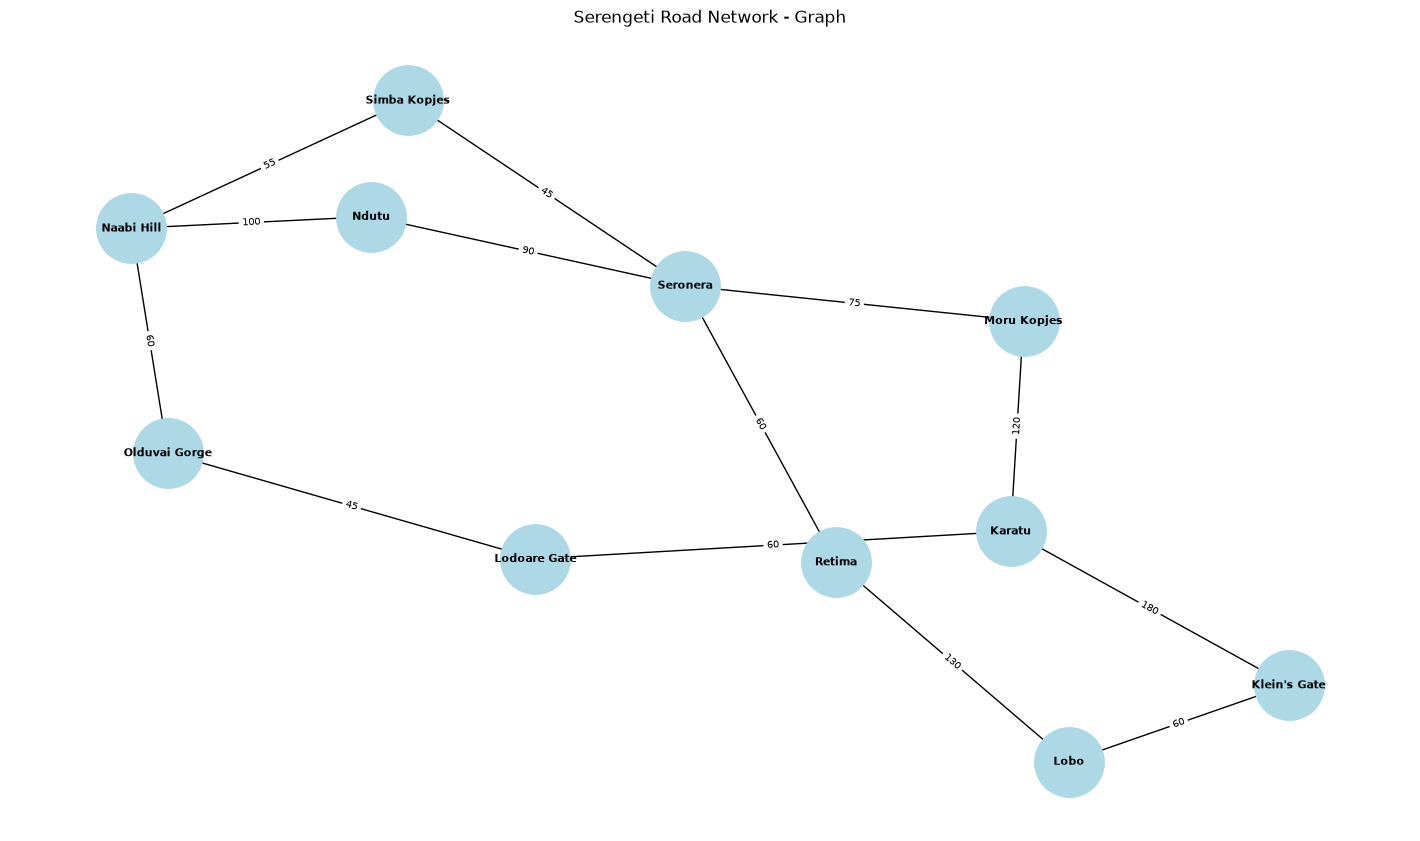

In [16]:
plt.figure(figsize=(14, 8))
nx.draw(G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2500,
        font_size=8,
        font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Serengeti Road Network - Graph")
plt.tight_layout()
plt.show()